In [ ]:
!pip install lightning torch torchmetrics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 51.8 MB/s eta 0:00:00


In [ ]:
import random
from typing import Literal, Optional

import numpy as np
import lightning as pl
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import torch
from torch import nn
from torchmetrics.classification import BinaryAccuracy
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from dataclasses import dataclass, field
import math


@dataclass
class DatasetConfig:

    IMAGE_SIZE:int = 128
    SYMBOL_SIZE:int = 14          # side length for each symbol
    SYMBOL_PADDING:int = 2        # minimum gap between symbol
    NUM_SYMBOLS:int = 6           # total distinct symbols

    MIN_INSTANCES:int = 6
    MAX_INSTANCES:int = 12

    SYMBOLS = ["+", "-", "|", "X", "O", "o"]


class RenderingFunctions:

    @staticmethod
    def draw_symbol(draw: ImageDraw.ImageDraw, symbol: str, x: int, y: int, size: int) -> None:
        # Draw 'symbol' centred at pixel (x, y) inside a box 'size' px.
        half = size // 2
        lw = max(1, size // 7)  # line width scales with symbol size

        x0, y0 = x - half, y - half
        x1, y1 = x + half, y + half

        if symbol == "+":
            draw.line([(x, y0), (x, y1)], fill=255, width=lw)
            draw.line([(x0, y), (x1, y)], fill=255, width=lw)

        elif symbol == "-":
            draw.line([(x0, y), (x1, y)], fill=255, width=lw)

        elif symbol == "|":
            draw.line([(x, y0), (x, y1)], fill=255, width=lw)

        elif symbol == "X":
            draw.line([(x0, y0), (x1, y1)], fill=255, width=lw)
            draw.line([(x1, y0), (x0, y1)], fill=255, width=lw)

        elif symbol == "O":
            draw.ellipse([x0, y0, x1, y1], outline=255, width=lw)

        elif symbol == "o":
            draw.ellipse([x0, y0, x1, y1], fill=255)


    @staticmethod
    def get_centers_coords(
        n: int,
        img_size: int,
        sym_size: int,
        padding: int,
        rng: random.Random,
        coverage: float
    ) -> list[tuple[int, int]]:
        # Generates random center positions that are more or less "clustered"

        step = sym_size + padding

        # Based on the coverage param determine a subgrid that fits
        # all the symbols
        min_cells_side = math.ceil(math.sqrt(n))
        min_area_size = min_cells_side * step

        active_size = max(min_area_size, int(img_size * coverage))
        grid_n = active_size // step

        local_cells = [(c * step + step // 2, r * step + step // 2)
                    for r in range(grid_n) for c in range(grid_n)]

        if n > len(local_cells):
            raise RuntimeError(f"Coverage {coverage} too small to fit {n} points.")

        # Sample points on this subgrid
        selected = rng.sample(local_cells, n)

        # Place the subgrid (containing the original points)
        # within the entire grid
        max_offset = img_size - active_size
        offset_x = rng.randint(0, max_offset) if max_offset > 0 else 0
        offset_y = rng.randint(0, max_offset) if max_offset > 0 else 0

        return [(x + offset_x, y + offset_y) for x, y in selected]

    @staticmethod
    def generate_unordered_image(
        positive: bool,
        rng: random.Random,
        cfg: DatasetConfig,
        coverage:float
    ) -> tuple[np.ndarray, int]:

        n_instances = rng.randint(cfg.MIN_INSTANCES, cfg.MAX_INSTANCES)
        positions = RenderingFunctions.get_centers_coords(
            n_instances,
            cfg.IMAGE_SIZE,
            cfg.SYMBOL_SIZE,
            cfg.SYMBOL_PADDING,
            rng,
            coverage
        )

        if positive:
            # Select all symbols and add random extra symbols
            chosen = cfg.SYMBOLS[:]
            extra = [rng.choice(cfg.SYMBOLS) for _ in range(n_instances - cfg.NUM_SYMBOLS)]
            chosen.extend(extra)
            rng.shuffle(chosen)
        else:
            # Remove at least one symbol for sampling
            n_missing = rng.randint(1, cfg.NUM_SYMBOLS - 1)
            available = rng.sample(cfg.SYMBOLS, cfg.NUM_SYMBOLS - n_missing)
            # Sample from the remaining symbols
            chosen = [rng.choice(available) for _ in range(n_instances)]

        img = Image.new("L", (cfg.IMAGE_SIZE, cfg.IMAGE_SIZE), color=0)
        draw = ImageDraw.Draw(img)
        for (cx, cy), sym in zip(positions, chosen):
            RenderingFunctions.draw_symbol(draw, sym, cx, cy, cfg.SYMBOL_SIZE)

        return np.array(img, dtype=np.uint8), int(positive)



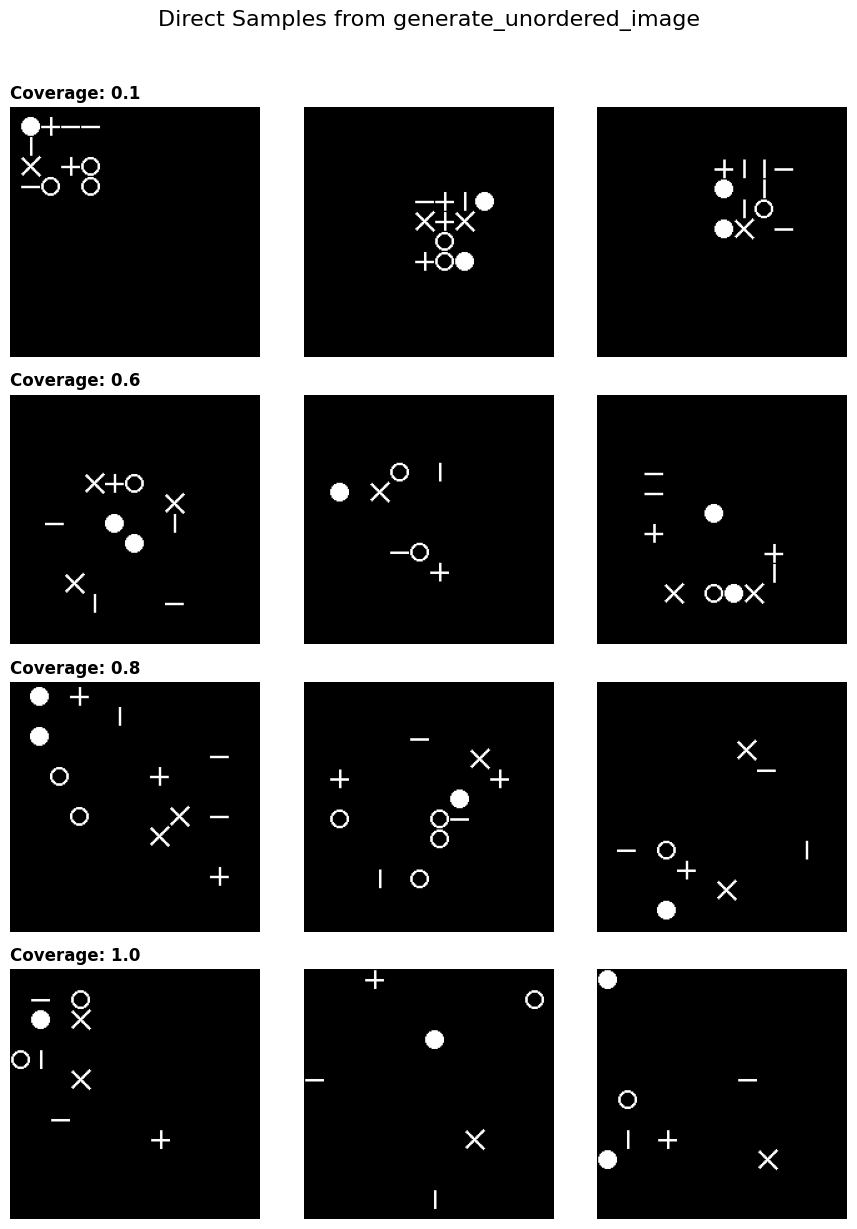

In [ ]:
import matplotlib.pyplot as plt

def visualize_dataset_generation(coverage_levels: list[float], samples_per_level: int = 3):
    cfg = DatasetConfig(
        IMAGE_SIZE=200
        )
    rng = random.Random(42)

    n_rows = len(coverage_levels)
    fig, axes = plt.subplots(n_rows, samples_per_level, figsize=(samples_per_level * 3, n_rows * 3))

    if n_rows == 1: axes = [axes]

    for row_idx, cov in enumerate(coverage_levels):
        for col_idx in range(samples_per_level):
            ax = axes[row_idx][col_idx]

            img_array, label = RenderingFunctions.generate_unordered_image(
                positive=True,
                rng=rng,
                cfg=cfg,
                coverage=cov
            )

            ax.imshow(img_array, cmap='gray')
            ax.axis('off')

            if col_idx == 0:
                ax.set_title(f"Coverage: {cov}", loc='left', fontweight='bold')

    plt.suptitle("Direct Samples from generate_unordered_image", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_dataset_generation(coverage_levels=[0.1, 0.6, 0.8, 1.0])

In [ ]:
class SymbolDataset(Dataset):
    def __init__(self,
          coverage: float,
          cfg: DatasetConfig,
          size: int = 10_000,
          positive_ratio: float = 0.5,
          seed: int = 42,
          normalize_params: tuple[float, float] = None
        ) -> None:
        super().__init__()
        self.coverage = coverage
        self.cfg = cfg
        self.size = size
        self.normalize_params = normalize_params

        rng = random.Random(seed)
        labels = [rng.random() < positive_ratio for _ in range(size)]

        # Generate data
        self.xy = [
            RenderingFunctions.generate_unordered_image(
                positive=label, rng=rng, cfg=cfg, coverage=self.coverage
            ) for label in labels
        ]

    def __len__(self) -> int:
        return len(self.xy)

    def get_stats(self):

        # Stack all images
        all_imgs = np.stack([item[0] for item in self.xy]).astype(np.float32).reshape(self.size, -1)
        # Normalize
        all_imgs = all_imgs / 255.0

        return all_imgs.mean(), all_imgs.std()

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        arr, label = self.xy[idx]

        # Convert to float tensor [1, H, W] in range [0, 1]
        img = torch.from_numpy(arr).float().unsqueeze(0) / 255.0

        # Apply normalization if params are provided
        if self.normalize_params:
            mean, std = self.normalize_params
            img = (img - mean) / (std + 1e-7) # Add epsilon to avoid dividing by zero

        return img, torch.tensor(label, dtype=torch.long)

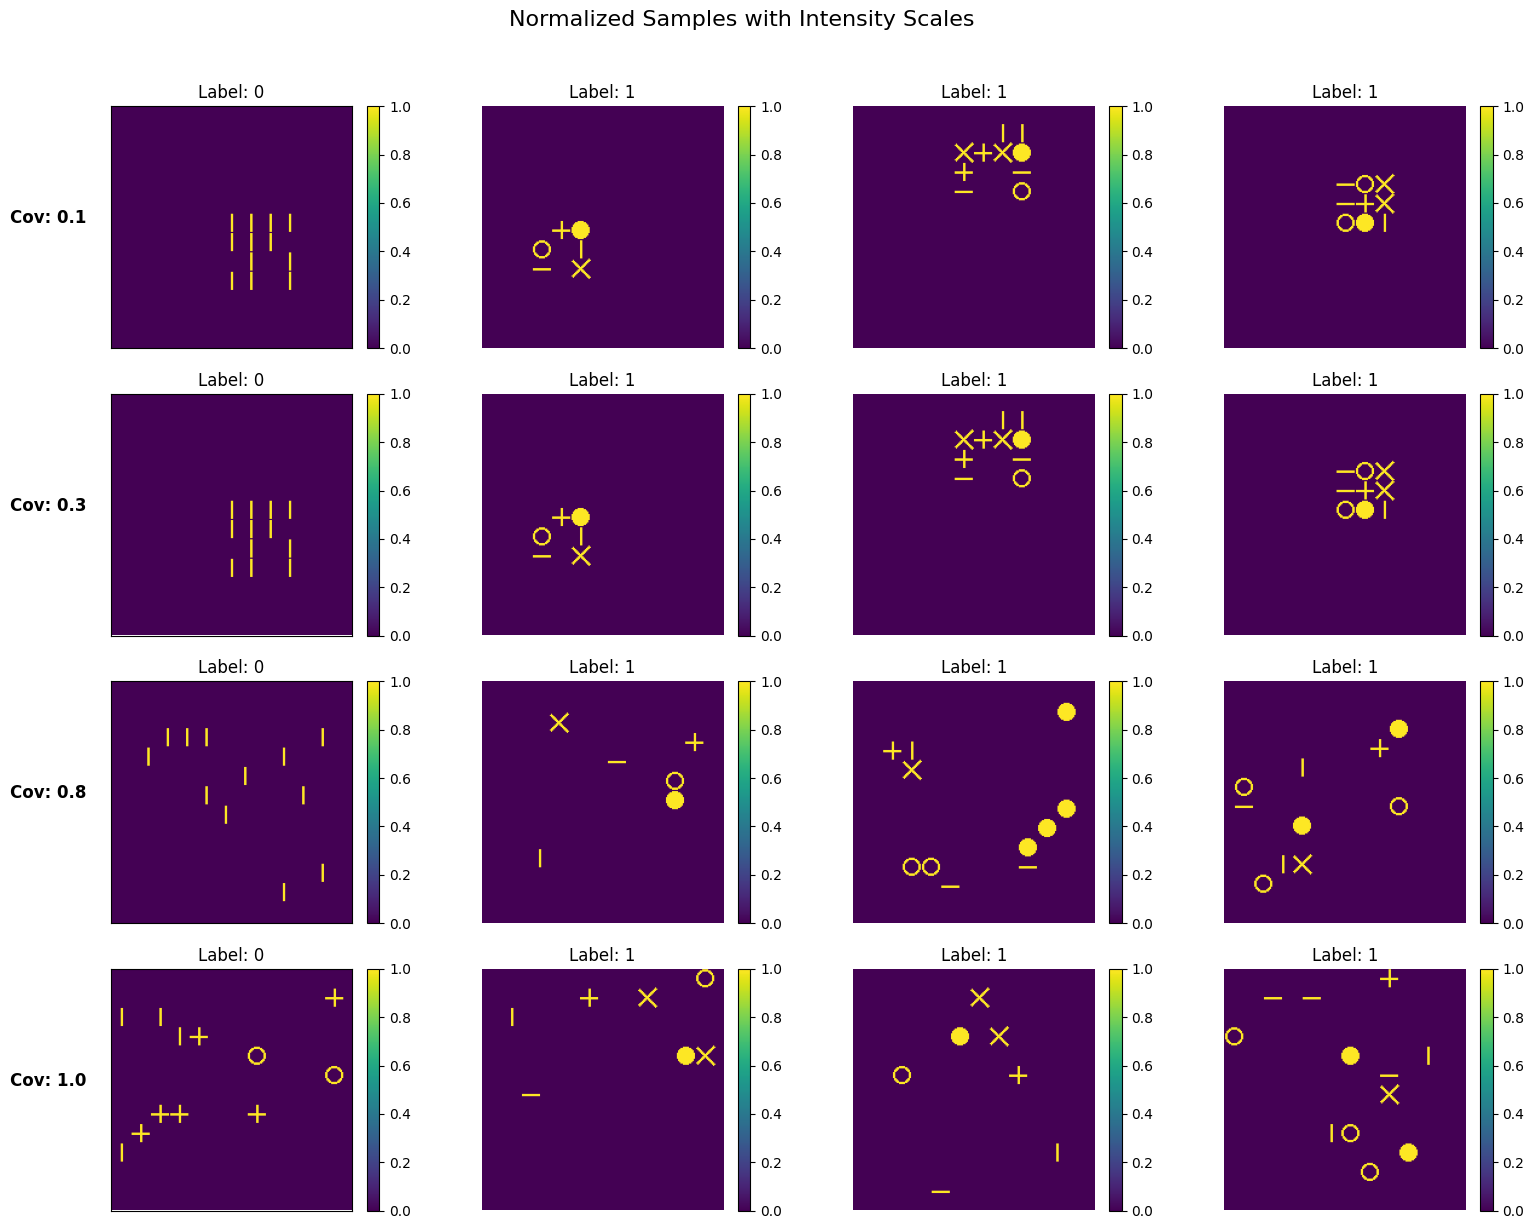

In [ ]:
import matplotlib.pyplot as plt

def visualize_dataset_samples(coverage_levels: list[float], n_samples: int = 4):
    cfg = DatasetConfig(IMAGE_SIZE=200, SYMBOL_SIZE=14)

    n_rows = len(coverage_levels)

    fig, axes = plt.subplots(n_rows, n_samples, figsize=(n_samples * 4, n_rows * 3), squeeze=False)

    for row_idx, cov in enumerate(coverage_levels):

        dataset = SymbolDataset(coverage=cov, cfg=cfg, size=20, seed=42)

        for col_idx in range(n_samples):
            ax = axes[row_idx, col_idx]

            img_tensor, label = dataset[col_idx]
            img_array = img_tensor.squeeze().numpy()

            im = ax.imshow(img_array, cmap='viridis')
            ax.axis('off')

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            ax.set_title(f"Label: {label.item()}")

            if col_idx == 0:
                ax.set_ylabel(f"Cov: {cov}", rotation=0, labelpad=45, fontsize=12, fontweight='bold')
                ax.axis('on')
                ax.set_xticks([])
                ax.set_yticks([])

    plt.suptitle("Normalized Samples with Intensity Scales", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

visualize_dataset_samples(coverage_levels=[0.1, 0.3, 0.8, 1.0])

In [ ]:
ds = SymbolDataset(1.0, DatasetConfig())
ds.get_stats()

(np.float32(0.041773003), np.float32(0.2000709))

In [ ]:
class SymbolDataModule(pl.LightningDataModule):

    def __init__(
        self,
        coverage: float,
        cfg: DatasetConfig,
        train_size: int = 10_000,
        val_size: int = 2_000,
        test_size: int = 2_000,
        positive_ratio: float = 0.5,
        batch_size: int = 256,
        num_workers: int = 2,
        seed: int = 0,
    ) -> None:
        super().__init__()
        self.save_hyperparameters()

        self.cfg = cfg
        self.coverage = coverage
        self.train_size = train_size
        self.val_size = val_size
        self.test_size = test_size
        self.positive_ratio = positive_ratio
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.seed = seed

        self.norm_stats = None

    def setup(self, stage: Optional[str] = None) -> None:

        train_raw = SymbolDataset(
            coverage=self.coverage,
            cfg=self.cfg,
            size=self.train_size,
            seed=self.seed
        )
        self.norm_stats = train_raw.get_stats()

        if stage in ("fit", None):
            self.train_dataset = SymbolDataset(
                coverage=self.coverage,
                cfg=self.cfg,
                size=self.train_size,
                seed=self.seed,
                normalize_params=self.norm_stats
            )
            self.val_dataset = SymbolDataset(
                coverage=self.coverage,
                cfg=self.cfg,
                size=self.val_size,
                seed=self.seed + 42,
                normalize_params=self.norm_stats
            )

        if stage in ("test", None):
            self.test_dataset = SymbolDataset(
                coverage=self.coverage,
                cfg=self.cfg,
                size=self.test_size,
                seed=self.seed + 84,
                normalize_params=self.norm_stats
            )

    def sample_batch(self, n: int = 4) -> tuple[torch.Tensor, torch.Tensor]:
        if not hasattr(self, 'train_dataset'):
            self.setup("fit")

        loader = self.train_dataloader()
        # Get one batch and slice it
        imgs, labels = next(iter(loader))
        return imgs[:n], labels[:n]

    def train_dataloader(self) -> DataLoader:
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers
        )

    def val_dataloader(self) -> DataLoader:
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )

    def test_dataloader(self) -> DataLoader:
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )


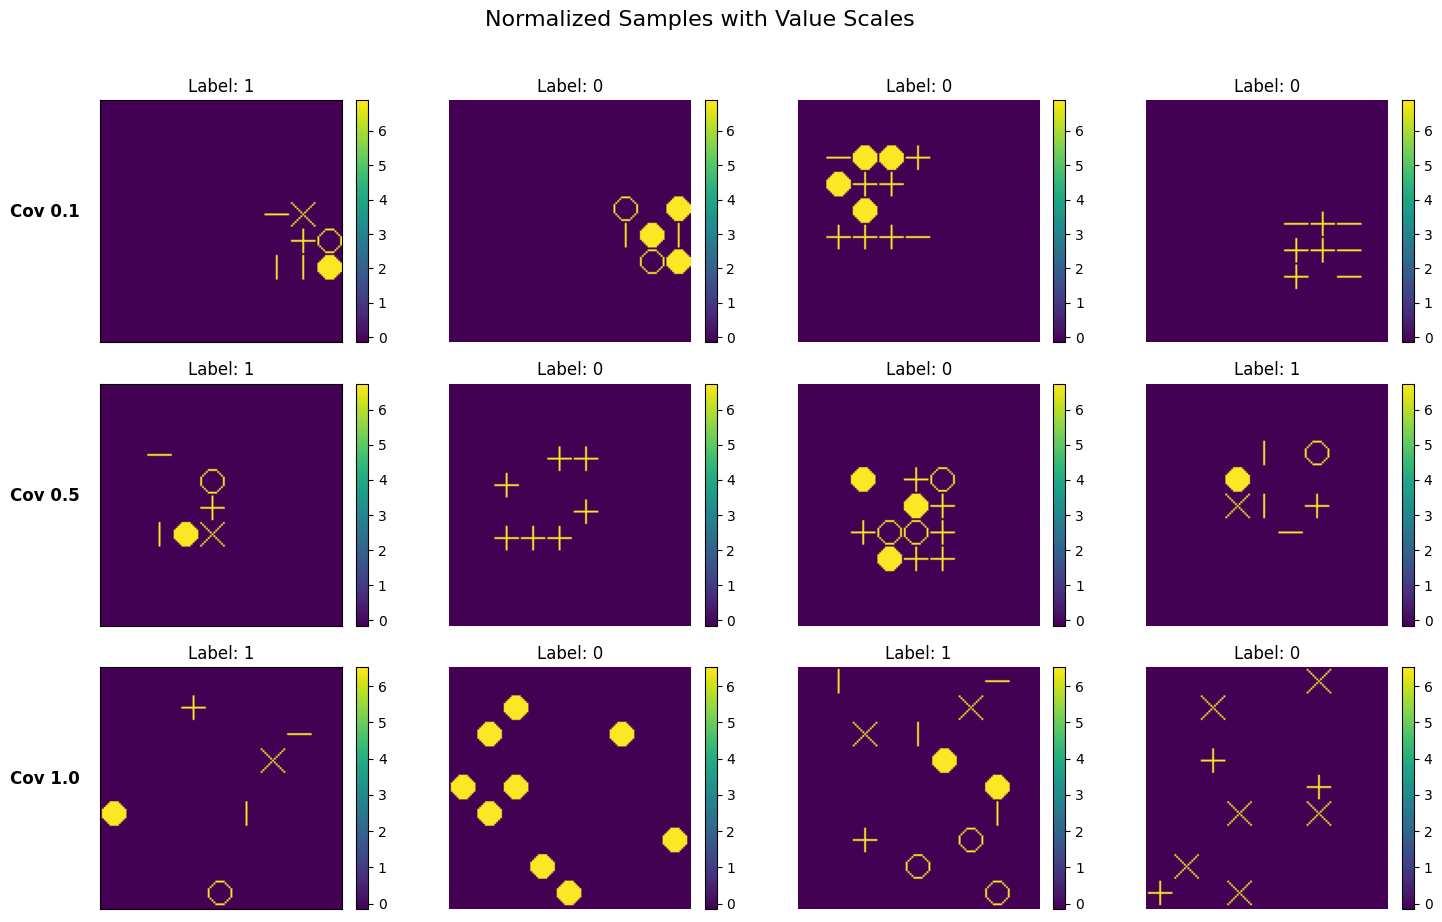

In [ ]:
import matplotlib.pyplot as plt

def plot_datamodule_samples(coverage_levels=[0.1, 0.5, 1.0]):
    cfg = DatasetConfig(IMAGE_SIZE=128, SYMBOL_SIZE=12)

    n_rows = len(coverage_levels)
    n_cols = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))

    if n_rows == 1: axes = axes.reshape(1, -1)

    for i, cov in enumerate(coverage_levels):
        dm = SymbolDataModule(coverage=cov, cfg=cfg, train_size=100, batch_size=n_cols)
        imgs, labels = dm.sample_batch(n=n_cols)

        for j in range(n_cols):
            ax = axes[i, j]
            img = imgs[j].squeeze().numpy()

            im = ax.imshow(img, cmap='viridis')
            ax.set_title(f"Label: {labels[j].item()}")
            ax.axis('off')

            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        axes[i, 0].axis('on')
        axes[i, 0].set_ylabel(f"Cov {cov}", rotation=0, labelpad=40, fontweight='bold', fontsize=12)
        axes[i, 0].set_xticks([])
        axes[i, 0].set_yticks([])

    plt.suptitle("Normalized Samples with Value Scales", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_datamodule_samples()

In [ ]:

class TinyCNN(nn.Module):

    def __init__(
            self,
            channels_in: int,
            first_kernel_size: int,
            mlp_hideen_size: int,
            num_classes: int = 2,
            H=32,
            W=32,
        ):
        super().__init__()

        assert first_kernel_size // 2 >= 2, 'Second kernel must be of size 2x2 at least'

        self.conv = nn.Sequential(
            nn.Conv2d(
                channels_in,
                channels_in * 3,
                kernel_size=first_kernel_size
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                channels_in * 3,
                (channels_in * 3) * 3 ,
                kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                channels_in * 9 ,
                (channels_in * 9 ) * 3 * 2 ,
                kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        with torch.no_grad():
            dummy = torch.zeros((1, channels_in, H, W))
            n_features = self.conv(dummy).numel()

        self.mlp_head = nn.Sequential(
            nn.Linear(n_features, mlp_hideen_size),
            nn.ReLU(),
            nn.Linear(mlp_hideen_size, num_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.mlp_head(x)
        return x


class CNNLightningModule(pl.LightningModule):

    def __init__(
        self,
        channels_in: int,
        first_kernel_size: int,
        mlp_hideen_size: int,
        num_classes: int = 2,
        H=32,
        W=32,
        lr: float = 1e-3,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr

        self.model = TinyCNN(
            channels_in=channels_in,
            first_kernel_size=first_kernel_size,
            mlp_hideen_size=mlp_hideen_size,
            num_classes=num_classes,
            H=H,
            W=W,
        )

        self.criterion = nn.CrossEntropyLoss()

        self.train_acc = BinaryAccuracy()
        self.val_acc   = BinaryAccuracy()
        self.test_acc  = BinaryAccuracy()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def _shared_step(self, batch):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=-1)
        return loss, preds, y

    def training_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.train_acc(preds, y)
        self.log("train/loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train/acc",  self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.val_acc(preds, y)
        self.log("val/loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val/acc",  self.val_acc,  on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.test_acc(preds, y)
        self.log("test/loss", loss)
        self.log("test/acc",  self.test_acc)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr)
        return {"optimizer": optimizer}

In [ ]:


class PatchEmbedding(nn.Module):
    """Splits image into patches and linearly projects them into embedding space."""

    def __init__(self, img_size: int, patch_size: int, in_channels: int, embed_dim: int):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)        # (B, embed_dim, n_patches^0.5, n_patches^0.5)
        x = x.flatten(2)        # (B, embed_dim, n_patches)
        x = x.transpose(1, 2)  # (B, n_patches, embed_dim)
        return x


class TransformerEncoderBlock(nn.Module):

    def __init__(self, embed_dim: int, n_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class ViT(nn.Module):

    def __init__(
        self,
        img_size: int = 64,
        patch_size: int = 4,
        in_channels: int = 1,
        num_classes: int = 2,
        embed_dim: int = 128,
        depth: int = 4,
        n_heads: int = 4,
        mlp_ratio: float = 2.0,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        self.blocks = nn.Sequential(
            *[TransformerEncoderBlock(embed_dim, n_heads, mlp_ratio, dropout) for _ in range(depth)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.size(0)
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.pos_drop(x + self.pos_embed)
        x = self.blocks(x)
        x = self.norm(x)
        return self.head(x[:, 0])


class ViTLightningModule(pl.LightningModule):

    def __init__(
        self,
        num_classes: int = 2,
        patch_size: int = 8,
        embed_dim: int = 70,
        depth: int = 4,
        n_heads: int = 5,
        mlp_ratio: float = 2.0,
        dropout: float = 0.1,
        lr: float = 1e-3,
        img_size: int = 64,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr

        self.model = ViT(
            img_size=img_size,
            patch_size=patch_size,
            num_classes=num_classes,
            embed_dim=embed_dim,
            depth=depth,
            n_heads=n_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )
        self.criterion = nn.CrossEntropyLoss()

        self.train_acc = BinaryAccuracy()
        self.val_acc   = BinaryAccuracy()
        self.test_acc  = BinaryAccuracy()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def _shared_step(self, batch):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=-1)
        return loss, preds, y

    def training_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.train_acc(preds, y)
        self.log("train/loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train/acc",  self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.val_acc(preds, y)
        self.log("val/loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val/acc",  self.val_acc,  on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.test_acc(preds, y)
        self.log("test/loss", loss)
        self.log("test/acc",  self.test_acc)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.lr
        )
        return {'optimizer':optimizer}

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



 Starting Experiment: Coverage = 0.1
Training ViT...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ViT              │  182 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_acc │ BinaryAccuracy   │      0 │ train │     0 │
│ 3 │ val_acc   │ BinaryAccuracy   │      0 │ train │     0 │
│ 4 │ test_acc  │ BinaryAccuracy   │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 182 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 182 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 55                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ TinyCNN          │  180 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_acc │ BinaryAccuracy   │      0 │ train │     0 │
│ 3 │ val_acc   │ BinaryAccuracy   │      0 │ train │     0 │
│ 4 │ test_acc  │ BinaryAccuracy   │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 180 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 180 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 19                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

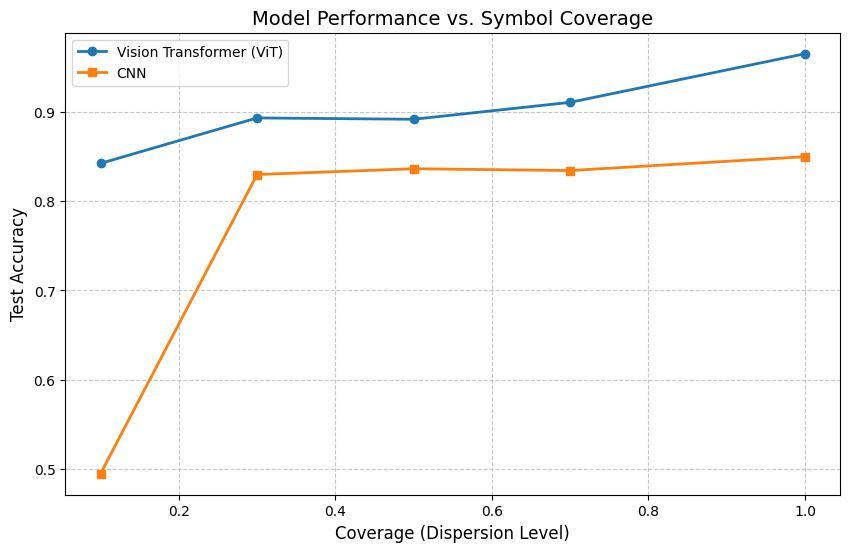

In [ ]:

def run_coverage_experiment(coverage_levels: list[float], epochs: int = 25):

    pl.seed_everything(42)

    cfg = DatasetConfig(IMAGE_SIZE=128, SYMBOL_SIZE=12)
    results = {"vit": [], "cnn": []}

    for cov in coverage_levels:
        print(f"\n Starting Experiment: Coverage = {cov}")

        dm = SymbolDataModule(
            coverage=cov,
            cfg=cfg,
            train_size=5000,
            val_size=1000,
            batch_size=256
          )

        print("Training ViT...")
        vit_model = ViTLightningModule(img_size=cfg.IMAGE_SIZE, num_classes=2)
        vit_trainer = pl.Trainer(
            max_epochs=epochs,
            accelerator="auto",
            enable_checkpointing=False,
            logger=False,
            enable_model_summary=True,
            enable_progress_bar=True,
            callbacks=[
                EarlyStopping(
                    monitor='val/loss',
                    mode='min',
                    patience=5
                  )
            ]
          )
        vit_trainer.fit(vit_model, datamodule=dm)
        vit_test = vit_trainer.test(vit_model, datamodule=dm, verbose=False)
        results["vit"].append(vit_test[0]["test/acc"])

        print("Training CNN...")
        cnn_model = CNNLightningModule(
            channels_in=1,
            first_kernel_size=30,
            mlp_hideen_size=32,
            H=cfg.IMAGE_SIZE,
            W=cfg.IMAGE_SIZE
        )
        cnn_trainer = pl.Trainer(
            max_epochs=epochs,
            accelerator="auto",
            enable_checkpointing=False,
            logger=False,
            enable_model_summary=True,
            enable_progress_bar=True,
            callbacks=[
                EarlyStopping(
                    monitor='val/loss',
                    mode='min',
                    patience=5
                  )
            ]
          )
        cnn_trainer.fit(cnn_model, datamodule=dm)
        cnn_test = cnn_trainer.test(cnn_model, datamodule=dm, verbose=False)
        results["cnn"].append(cnn_test[0]["test/acc"])

    return results



def plot_results(coverage_levels, results):
    plt.figure(figsize=(10, 6))
    plt.plot(coverage_levels, results["vit"], marker='o', label='Vision Transformer (ViT)', linewidth=2)
    plt.plot(coverage_levels, results["cnn"], marker='s', label='CNN', linewidth=2)

    plt.title("Model Performance vs. Symbol Coverage", fontsize=14)
    plt.xlabel("Coverage (Dispersion Level)", fontsize=12)
    plt.ylabel("Test Accuracy", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()



# Define levels: 0.1 (clustered) to 1.0 (dispersed)
cov_levels = [0.1, 0.3, 0.5, 0.7, 1.0]

experiment_results = run_coverage_experiment(cov_levels, epochs=25)
plot_results(cov_levels, experiment_results)